In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd

from matplotlib import rcParams
# Use Arial for all math text
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Helvetica"
plt.rcParams["mathtext.it"] = "Helvetica:italic"
plt.rcParams["mathtext.bf"] = "Helvetica:bold"

# Use Arial for all normal text
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

In [3]:
nat_blue   = (74/255, 111/255, 165/255)   # Mediterranean sky blue
res_red    = (200/255, 74/255, 61/255)    # Vermilion / poppy red
increase_green  = (111/255, 143/255, 94/255)   # Olive landscape green
decrease_purple = (106/255, 76/255, 125/255)   # Muted aubergine purple
all_lake_neutral = (28/255, 24/255, 20/255)
grey_background = (235/255, 233/255, 228/255)

In [4]:
# Load data
df_lake_trends = pd.read_csv(
    "../../Processed_Data/WaterStorageTrend.txt",
    sep=r"\s+",        # whitespace-separated
    comment="#"
)

In [5]:
path = "../../Processed_Data/EQ_EF_LongTerm_Jackknife_Null_depth30km.txt"
df = pd.read_csv(path, sep=r"\t", engine="python")
# Convert to numeric + clean Inf/NaN
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan)
df = df[df["dmax_km"] <= 100]

In [6]:
path = "../../Processed_Data/EQ_within_20km_IncreaseLakes.txt"

df_eqI = pd.read_csv(path, sep=r"\t", engine="python")
# df_eqI.columns = ["Time", "Magnitude"]
df_eqI["Time"] = pd.to_numeric(df_eqI["Time"], errors="coerce")
df_eqI["Magnitude"] = pd.to_numeric(df_eqI["Magnitude"], errors="coerce")

df_eqI = df_eqI[df_eqI["Group"] == "Pos_Re"]
df_eqI = df_eqI[df_eqI["Depth_km"] <= 30]
df_eqI = df_eqI.dropna().sort_values("Time").reset_index(drop=True)

eqI_before = len(df_eqI[df_eqI["Time"]<2006])
eqI_after = len(df_eqI[df_eqI["Time"]>=2006])

In [7]:
path = "../../Processed_Data/EQ_within_20km_DecreaseLakes.txt"

df_eqD = pd.read_csv(path, sep=r"\t", engine="python")
# df_eqD.columns = ["Time", "Magnitude"]
df_eqD["Time"] = pd.to_numeric(df_eqD["Time"], errors="coerce")
df_eqD["Magnitude"] = pd.to_numeric(df_eqD["Magnitude"], errors="coerce")
df_eqD = df_eqD[df_eqD["Group"] == "Neg_Re"]
df_eqD = df_eqD[df_eqD["Depth_km"] <= 30]
df_eqD = df_eqD.dropna().sort_values("Time").reset_index(drop=True)

eqD_before = len(df_eqD[df_eqD["Time"]<2006])
eqD_after = len(df_eqD[df_eqD["Time"]>=2006])

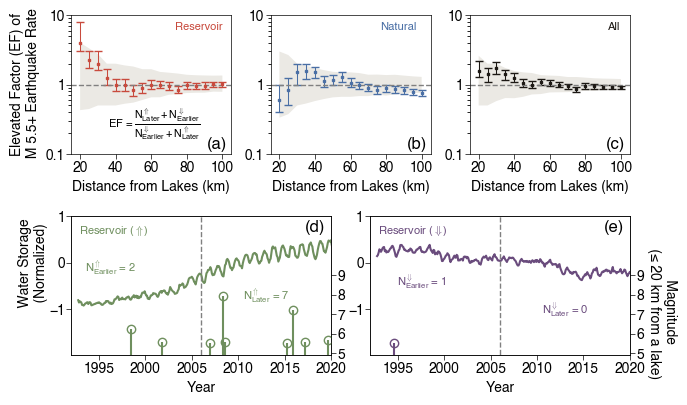

In [8]:
fig = plt.figure(figsize=(6.77, 4))

gs = GridSpec(
    2, 6,
    figure=fig,
    left=0.1, right=0.925,
    bottom=0.1, top=0.95,
    wspace=0.65,
    hspace=0.45
)

# --- Row 1: 2 equal subplots (each spans 1.5 columns) ---
ax1 = fig.add_subplot(gs[1, 0:3])  # spans 2/3 of row
ax2 = fig.add_subplot(gs[1, 3:6])    # spans 1/3 of row

# --- Row 2: 3 equal subplots ---
ax3 = fig.add_subplot(gs[0, 0:2])
ax4 = fig.add_subplot(gs[0, 2:4])
ax5 = fig.add_subplot(gs[0, 4:6])


# Left axis: lake trends
ax1.plot(
    df_lake_trends["Year"],
    df_lake_trends["Reservoir_Increase"],
    linestyle="-",
    linewidth=1.5,
    color=increase_green,
    label=r"Reservoir ($\Uparrow$)"
)

ax1.text(
    0.165, 0.95, r"Reservoir ($\Uparrow$)",
    transform=ax1.transAxes,
    ha="center", va="top",
    fontsize=8, color = increase_green
)

ax1.text(
    0.15, 0.7, (r"N$^{\Uparrow}_{Earlier}$ = "+f"{eqI_before}"),
    transform=ax1.transAxes,
    ha="center", va="top",
    fontsize=8, color = increase_green
)

ax1.text(
    0.75, 0.5, (r"N$^{\Uparrow}_{Later}$ = "+f"{eqI_after}"),
    transform=ax1.transAxes,
    ha="center", va="top",
    fontsize=8, color = increase_green
)

ax1.vlines(x = 2006, ymin = -100, ymax = 100, linewidths = 1, linestyles = '--', colors = 'grey')

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("            Water Storage\n            (Normalized)", fontsize=10, labelpad=1)

ax1.set_xticks(np.arange(1995, 2025, 5))
ax1.tick_params(axis='x', labelsize=10, pad = 1)
ax1.tick_params(axis='y', labelsize=10, pad = 1)
ax1.set_yticks(np.arange(-1,2, 1))
ax1.set_xlim(1992, 2020)
ax1.set_ylim(-2, 1)

# --- Right axis: earthquakes (stem) ---
ax1r = ax1.twinx()

ax1r.set_yticks(np.arange(5, 10, 1))
ax1r.tick_params(axis='y', labelsize=10, pad = 1)
ax1r.set_ylim(4.9, 12)
markerline1, stemlines1, baseline1 = ax1r.stem(df_eqI["Time"], df_eqI["Magnitude"],linefmt=increase_green, markerfmt='o')
markerline1.set_markerfacecolor('none')

ax2.plot(
    df_lake_trends["Year"], df_lake_trends["Reservoir_Decrease"],
    linestyle="-", linewidth=1.5,
    color=decrease_purple,
    label=r"Reservoir ($\Downarrow$)"
)
ax2.text(
    0.165, 0.95, r"Reservoir ($\Downarrow$)",
    transform=ax2.transAxes,
    ha="center", va="top",
    fontsize=8, color = decrease_purple
)

ax2.text(
    0.2, 0.6, (r"N$^{\Downarrow}_{Earlier}$ = "+f"{eqD_before}"),
    transform=ax2.transAxes,
    ha="center", va="top",
    fontsize=8, color = decrease_purple
)

ax2.text(
    0.75, 0.4, (r"N$^{\Downarrow}_{Later}$ = "+f"{eqD_after}"),
    transform=ax2.transAxes,
    ha="center", va="top",
    fontsize=8, color = decrease_purple
)

ax2.vlines(x = 2006, ymin = -100, ymax = 100, linewidths = 1, linestyles = '--', colors = 'grey')
# Formatting
ax2.set_xlabel("Year", fontsize=10)

ax2.set_xticks(np.arange(1995, 2025, 5))
ax2.set_yticks(np.arange(-1,2, 1))
ax2.tick_params(axis='x', labelsize=10, pad = 1)
ax2.tick_params(axis='y', labelsize=10, pad = 1)
ax2.set_xlim(1992, 2020)
ax2.set_ylim(-2, 1)

# --- Right axis: earthquakes (stem) ---
ax2r = ax2.twinx()
ax2r.set_yticks(np.arange(5, 10, 1))
ax2r.tick_params(axis='y', labelsize=10, pad = 1)
ax2r.set_ylim(4.9, 12)
markerline2, stemlines2, baseline2 = ax2r.stem(df_eqD["Time"], df_eqD["Magnitude"],linefmt=decrease_purple, markerfmt='o')
markerline2.set_markerfacecolor('none')
ax2r.set_ylabel("             Magnitude\n              (≤ 20 km from a lake)", fontsize=10, labelpad=24, rotation = -90)


# ALL
ax5.fill_between(df["dmax_km"], df["Null90_All_Low"], df["Null90_All_High"], alpha=1, color = grey_background, edgecolor = 'none')

ax5_yerr = [
    df["EF_All"] - df["Jack90_All_Low"],
    df["Jack90_All_High"] - df["EF_All"]
]
ax5.errorbar(x = df["dmax_km"], y = df["EF_All"], yerr=ax5_yerr, alpha=1
             , color = all_lake_neutral, linestyle = 'none', marker = 's',markersize = 2, markerfacecolor=all_lake_neutral, markeredgewidth=1
             , elinewidth=0.75   # width of error bar lines
             , capsize=3        # length of caps
             , capthick=0.75      # thickness of caps
             )

ax5.axhline(1, linestyle="--", linewidth=1, color = 'grey')
ax5.text(
    0.9, 0.95, "All",
    transform=ax5.transAxes,
    ha="center", va="top",
    fontsize=8, color = all_lake_neutral
)

ax5.tick_params(axis='x', labelsize=10, pad = 1)
ax5.tick_params(axis='y', labelsize=10, pad = 1)
ax5.set_xticks(np.arange(20, 101, 20))
ax5.set_xlim(15, 105)
ax5.set_xlabel("Distance from Lakes (km)")
ax5.set_ylim(0.1,10)
ax5.set_yscale('log')
ax5.set_yticks(10**(np.linspace(-1,1,3)))
ax5.set_yticklabels(['0.1','1','10'])

# Reservoir
ax3.fill_between(df["dmax_km"], df["Null90_Re_Low"], df["Null90_Re_High"], alpha=1, color = grey_background, edgecolor = 'none')

ax3_yerr = [
    df["EF_Reservoir"] - df["Jack90_Re_Low"],
    df["Jack90_Re_High"] - df["EF_Reservoir"]
]
ax3.errorbar(x = df["dmax_km"], y = df["EF_Reservoir"], yerr=ax3_yerr, alpha=1
             , color = res_red, linestyle = 'none', marker = 's',markersize = 2, markerfacecolor=res_red, markeredgewidth=1
             , elinewidth=0.75   # width of error bar lines
             , capsize=3        # length of caps
             , capthick=0.75      # thickness of caps
             )

ax3.axhline(1, linestyle="--", linewidth=1, color = 'grey')
ax3.text(
    0.8, 0.95, "Reservoir",
    transform=ax3.transAxes,
    ha="center", va="top",
    fontsize=8, color = res_red
)
ax3.text(
    0.3, 0.27, (r" $EF$ = "),
    transform=ax3.transAxes,
    ha="center", va="top",
    fontsize=8, color = 'k'
)

ax3.text(
    0.6, 0.35, (r"$\frac{\it{N}^{\Uparrow}_{Later}+N^{\Downarrow}_{Earlier}}{N^{\Downarrow}_{Earlier}+N^{\Uparrow}_{Later}}$"),
    transform=ax3.transAxes,
    ha="center", va="top",
    fontsize=11, color = 'k'
)

ax3.set_xlabel("Distance from Lakes (km)")
# ax3.set_ylabel("Enhance ratio")
ax3.set_ylabel("Elevated Factor (EF) of\n M 5.5+ Earthquake Rate")
ax3.tick_params(axis='x', labelsize=10, pad = 1)
ax3.tick_params(axis='y', labelsize=10, pad = 1)
ax3.set_xticks(np.arange(20, 101, 20))
ax3.set_xlim(15, 105)
ax3.set_ylim(0.1,10)
ax3.set_yscale('log')
ax3.set_yticks(10**(np.linspace(-1,1,3)))
ax3.set_yticklabels(['0.1','1','10'])

# Natural
ax4.fill_between(df["dmax_km"], df["Null90_Na_Low"], df["Null90_Na_High"], alpha=1, color = grey_background, edgecolor = 'none')
ax4_yerr = [
    df["EF_Natural"] - df["Jack90_Na_Low"],
    df["Jack90_Na_High"] - df["EF_Natural"]
]
ax4.errorbar(x = df["dmax_km"], y = df["EF_Natural"], yerr=ax4_yerr, alpha=1
             , color = nat_blue, linestyle = 'none', marker = 's',markersize = 2, markerfacecolor=nat_blue, markeredgewidth=1
             , elinewidth=0.75   # width of error bar lines
             , capsize=3        # length of caps
             , capthick=0.75      # thickness of caps
             )
# ax4.plot(df["dmax_km"], df["EF_Natural"], color = line_green, ls ="-",  linewidth=1.5)
ax4.axhline(1, linestyle="--", linewidth=1, color = 'grey')
ax4.text(
    0.8, 0.95, "Natural",
    transform=ax4.transAxes,
    ha="center", va="top",
    fontsize=8, color = nat_blue
)
ax4.set_xlabel("Distance from Lakes (km)")
ax4.tick_params(axis='x', labelsize=10, pad = 1)
ax4.tick_params(axis='y', labelsize=10, pad = 1)
ax4.set_xticks(np.arange(20, 101, 20))
ax4.set_xlim(15,105)
ax4.set_ylim(0.1,10)
ax4.set_yscale('log')
ax4.set_yticks(10**(np.linspace(-1,1,3)))
ax4.set_yticklabels(['0.1','1','10'])


for ax in [ax1, ax2, ax3, ax4, ax5, ax1r, ax2r]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

### Frame Style ###
for ax, label in [(ax3, '(a)'), (ax4, '(b)'), (ax5, '(c)')]:
    ax.text(0.85, 0.125, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)
for ax, label in [(ax1, '(d)'), (ax2, '(e)')]:
    ax.text(0.9, 0.975, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)

# Save for submission
plt.savefig("fig2.pdf", dpi=600)
plt.savefig("fig2.png", dpi=600)
plt.show()